# Notebook for generating off-grid test set data

## 1. Choose geometries
Generate off-grid geometries. 

To ensure even coverage of the 2D space, quasi-random selection algorithms (Sobol, Latin Hypercube) are used and compared to random selection.

Points too close to grid points (by `min_grid_separation_fraction`) and other selected points (by `min_test_separation_fraction`) are rejected.

### 1.1. Imports, settings, setup

In [75]:
import warnings
from pathlib import Path

import ase.io
import numpy as np
from ase import Atoms
from scipy.stats import qmc

# Sampling settings
N_GEOMETRIES = 128
seed = 42
min_grid_separation_fraction = 0.1
min_test_separation_fraction = 0.1
MAX_CANDIDATE_MULTIPLIER = 100  # if selections keep getting rejected, code will fail rather than try forever

ROOT_PATH = Path.cwd()
DATA_DIR = ROOT_PATH / "../data"
grid_path = DATA_DIR / "A02_propene_grid_static_2e2o.xyz"
grid_atoms = ase.io.read(grid_path, index=':3731')

grid_bonds = np.array([atoms.get_distance(0, 1) for atoms in grid_atoms])
grid_dihedrals = np.array([atoms.get_dihedral(4, 0, 1, 3) for atoms in grid_atoms])
bond_grid = np.unique(np.sort(grid_bonds))
dihedral_grid = np.unique(np.sort(grid_dihedrals))

def circular_distance_degrees(first, second):
    """Smallest angular distance in degrees, treating angles modulo 360."""
    return abs((first - second + 180.0) % 360.0 - 180.0)

def local_spacings(values, circular=False):
    """Nearest-neighbour grid spacing at every sorted grid value."""
    spacings = np.empty(len(values))
    for index, value in enumerate(values):
        distances = (
            circular_distance_degrees(value, values)
            if circular
            else np.abs(value - values)
        )
        spacings[index] = np.min(distances[distances > 0.0])
    return spacings

bond_spacings = local_spacings(bond_grid)
dihedral_spacings = local_spacings(dihedral_grid, circular=True)

def nearest_grid_value_and_spacing(value, values, spacings, circular=False):
    distances = (
        circular_distance_degrees(value, values)
        if circular
        else np.abs(value - values)
    )
    nearest_index = int(np.argmin(distances))
    return distances[nearest_index], spacings[nearest_index]

def is_too_close_to_grid(bond_length, dihedral):
    bond_distance, bond_spacing = nearest_grid_value_and_spacing(
        bond_length, bond_grid, bond_spacings
    )
    angle_distance, angle_spacing = nearest_grid_value_and_spacing(
        dihedral, dihedral_grid, dihedral_spacings, circular=True
    )
    # A shared coordinate is allowed; both coordinates must be near a grid value to be considered 'too close'.
    return (
        bond_distance < min_grid_separation_fraction * bond_spacing
        and angle_distance < min_grid_separation_fraction * angle_spacing
    )

def is_near_accepted_point(bond_length, dihedral, accepted_points):
    for accepted_bond, accepted_dihedral in accepted_points:
        _, bond_spacing = nearest_grid_value_and_spacing(
            accepted_bond, bond_grid, bond_spacings
        )
        _, angle_spacing = nearest_grid_value_and_spacing(
            accepted_dihedral, dihedral_grid, dihedral_spacings, circular=True
        )
        if (
            abs(bond_length - accepted_bond) < min_test_separation_fraction * bond_spacing
            and circular_distance_degrees(dihedral, accepted_dihedral)
            < min_test_separation_fraction * angle_spacing
        ):
            return True
    return False

# Select a canonical geometry at the minimum bond length and zero dihedral.
canonical_index = int(
    np.argmin(np.abs(grid_bonds - bond_grid[0]) + circular_distance_degrees(grid_dihedrals, 0.0))
)
canonical = grid_atoms[canonical_index]

def make_atoms(bond_length, dihedral):
    """Create a geometry-only propene Atoms object at the requested coordinates."""
    atoms = Atoms(
        symbols=canonical.get_chemical_symbols(),
        positions=canonical.get_positions(),
        cell=canonical.cell.copy(),
        pbc=canonical.pbc.copy(),
    )
    axis = atoms.positions[1] - atoms.positions[0]
    axis /= np.linalg.norm(axis)
    displacement = bond_length - atoms.get_distance(0, 1)
    atoms.positions[[1, 3, 5]] += displacement * axis
    rotate_mask = np.zeros(len(atoms), dtype=bool)
    rotate_mask[[3, 5]] = True
    atoms.set_dihedral(4, 0, 1, 3, dihedral, mask=rotate_mask)
    return atoms

lower_bounds = np.array([bond_grid[0], dihedral_grid[0]])
upper_bounds = np.array([bond_grid[-1], dihedral_grid[-1]])
max_candidates = max(N_GEOMETRIES * MAX_CANDIDATE_MULTIPLIER, N_GEOMETRIES)


### 1.2. Using random

In [67]:
random_seed = seed
random_generator = np.random.default_rng(random_seed)
random_accepted_points = []
random_candidates_drawn = 0

# The initial random draw has exactly N_GEOMETRIES candidates; later draws replace rejects.
random_candidate_batch = random_generator.uniform(
    lower_bounds, upper_bounds, size=(N_GEOMETRIES, 2)
)
while len(random_accepted_points) < N_GEOMETRIES:
    random_candidates_drawn += len(random_candidate_batch)
    for bond_length, dihedral in random_candidate_batch:
        if not is_too_close_to_grid(bond_length, dihedral) and not is_near_accepted_point(
            bond_length, dihedral, random_accepted_points
        ):
            random_accepted_points.append((float(bond_length), float(dihedral)))
            if len(random_accepted_points) == N_GEOMETRIES:
                break
    if len(random_accepted_points) == N_GEOMETRIES:
        break
    if random_candidates_drawn >= max_candidates:
        raise RuntimeError(
            f'Only {len(random_accepted_points)} random points accepted after '
            f'{random_candidates_drawn} candidates; reduce a separation fraction or '
            'increase MAX_CANDIDATE_MULTIPLIER.'
        )
    random_batch_size = min(
        max(N_GEOMETRIES - len(random_accepted_points), 64),
        max_candidates - random_candidates_drawn,
    )
    random_candidate_batch = random_generator.uniform(
        lower_bounds, upper_bounds, size=(random_batch_size, 2)
    )

random_test_set: list[Atoms] = [
    make_atoms(bond_length, dihedral)
    for bond_length, dihedral in random_accepted_points
]

# Validate the random off-grid set using the existing filtering rules.
assert len(random_test_set) == N_GEOMETRIES
assert len({id(atoms) for atoms in random_test_set}) == N_GEOMETRIES
assert all(not is_too_close_to_grid(*point) for point in random_accepted_points)
assert all(
    not is_near_accepted_point(*point, random_accepted_points[:index])
    for index, point in enumerate(random_accepted_points)
)
assert np.allclose(
    [atoms.get_distance(0, 1) for atoms in random_test_set],
    [point[0] for point in random_accepted_points],
)
assert np.allclose(
    [atoms.get_dihedral(4, 0, 1, 3) for atoms in random_test_set],
    [point[1] for point in random_accepted_points],
)

print(
    f'Generated {len(random_test_set)} random off-grid geometries from '
    f'{random_candidates_drawn} candidates.'
)


Generated 512 random off-grid geometries from 576 candidates.


### 1.3. Using Sobol

In [68]:
def sobol_random(sobol_sampler, n_points):
    # scipy warns for non-power-of-two batches; arbitrary N is intentional here.
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', message='The balance properties of Sobol.*')
        return sobol_sampler.random(n_points)

sampler = qmc.Sobol(d=2, scramble=True, seed=seed)
sobol_accepted_points = []
sobol_candidates_drawn = 0

# The first Sobol request is exactly N_GEOMETRIES; later batches replace rejects.
candidate_batch = sobol_random(sampler, N_GEOMETRIES)
while len(sobol_accepted_points) < N_GEOMETRIES:
    sobol_candidates_drawn += len(candidate_batch)
    for bond_length, dihedral in qmc.scale(candidate_batch, lower_bounds, upper_bounds):
        if not is_too_close_to_grid(bond_length, dihedral) and not is_near_accepted_point(
            bond_length, dihedral, sobol_accepted_points
        ):
            sobol_accepted_points.append((float(bond_length), float(dihedral)))
            if len(sobol_accepted_points) == N_GEOMETRIES:
                break
    if len(sobol_accepted_points) == N_GEOMETRIES:
        break
    if sobol_candidates_drawn >= max_candidates:
        raise RuntimeError(
            f'Only {len(sobol_accepted_points)} points accepted after {sobol_candidates_drawn} Sobol candidates; '
            'reduce a separation fraction or increase MAX_CANDIDATE_MULTIPLIER.'
        )
    candidate_batch = sobol_random(
        sampler, min(max(N_GEOMETRIES - len(sobol_accepted_points), 64), max_candidates - sobol_candidates_drawn)
    )

sobol_test_set: list[Atoms] = [make_atoms(bond_length, dihedral) for bond_length, dihedral in sobol_accepted_points]
test_set = sobol_test_set  # Backwards-compatible alias for the original Sobol result.

# In-cell validation of the sampling and constructed geometries.
assert len(test_set) == N_GEOMETRIES
assert len({id(atoms) for atoms in test_set}) == N_GEOMETRIES
assert all(isinstance(atoms, Atoms) for atoms in test_set)
assert all(not is_too_close_to_grid(*point) for point in sobol_accepted_points)
assert all(
    not is_near_accepted_point(*point, sobol_accepted_points[:index])
    for index, point in enumerate(sobol_accepted_points)
)
measured_bonds = np.array([atoms.get_distance(0, 1) for atoms in test_set])
measured_dihedrals = np.array([atoms.get_dihedral(4, 0, 1, 3) for atoms in test_set])
assert np.all((bond_grid[0] <= measured_bonds) & (measured_bonds <= bond_grid[-1]))
assert np.all((dihedral_grid[0] <= measured_dihedrals) & (measured_dihedrals <= dihedral_grid[-1]))
assert np.allclose(measured_bonds, [point[0] for point in sobol_accepted_points])
assert np.allclose(measured_dihedrals, [point[1] for point in sobol_accepted_points])
assert np.array_equal(
    sobol_random(qmc.Sobol(d=2, scramble=True, seed=seed), N_GEOMETRIES),
    sobol_random(qmc.Sobol(d=2, scramble=True, seed=seed), N_GEOMETRIES),
)
if N_GEOMETRIES:
    assert not np.array_equal(
        sobol_random(qmc.Sobol(d=2, scramble=True, seed=seed), N_GEOMETRIES),
        sobol_random(qmc.Sobol(d=2, scramble=True, seed=seed + 1), N_GEOMETRIES),
    )

print(f'Generated {len(test_set)} off-grid geometries from {sobol_candidates_drawn} Sobol candidates.')


Generated 512 off-grid geometries from 576 Sobol candidates.


### 1.3. Using Latin Hypercube

In [69]:
latin_seed = seed
latin_sampler = qmc.LatinHypercube(d=2, seed=latin_seed)
latin_accepted_points = []
latin_candidates_drawn = 0

# The initial Latin-hypercube draw has exactly N_GEOMETRIES candidates.
latin_candidate_batch = latin_sampler.random(N_GEOMETRIES)
while len(latin_accepted_points) < N_GEOMETRIES:
    latin_candidates_drawn += len(latin_candidate_batch)
    for bond_length, dihedral in qmc.scale(
        latin_candidate_batch, lower_bounds, upper_bounds
    ):
        if not is_too_close_to_grid(bond_length, dihedral) and not is_near_accepted_point(
            bond_length, dihedral, latin_accepted_points
        ):
            latin_accepted_points.append((float(bond_length), float(dihedral)))
            if len(latin_accepted_points) == N_GEOMETRIES:
                break
    if len(latin_accepted_points) == N_GEOMETRIES:
        break
    if latin_candidates_drawn >= max_candidates:
        raise RuntimeError(
            f'Only {len(latin_accepted_points)} Latin-hypercube points accepted after '
            f'{latin_candidates_drawn} candidates; reduce a separation fraction or '
            'increase MAX_CANDIDATE_MULTIPLIER.'
        )
    latin_batch_size = min(
        max(N_GEOMETRIES - len(latin_accepted_points), 64),
        max_candidates - latin_candidates_drawn,
    )
    latin_candidate_batch = latin_sampler.random(latin_batch_size)

latin_test_set: list[Atoms] = [
    make_atoms(bond_length, dihedral)
    for bond_length, dihedral in latin_accepted_points
]

assert len(latin_test_set) == N_GEOMETRIES
assert len({id(atoms) for atoms in latin_test_set}) == N_GEOMETRIES
assert all(not is_too_close_to_grid(*point) for point in latin_accepted_points)
assert all(
    not is_near_accepted_point(*point, latin_accepted_points[:index])
    for index, point in enumerate(latin_accepted_points)
)
assert np.allclose(
    [atoms.get_distance(0, 1) for atoms in latin_test_set],
    [point[0] for point in latin_accepted_points],
)
assert np.allclose(
    [atoms.get_dihedral(4, 0, 1, 3) for atoms in latin_test_set],
    [point[1] for point in latin_accepted_points],
)

print(
    f'Generated {len(latin_test_set)} Latin-hypercube off-grid geometries from '
    f'{latin_candidates_drawn} candidates.'
)


Generated 512 Latin-hypercube off-grid geometries from 576 candidates.


### 1.5. Visualise test sets

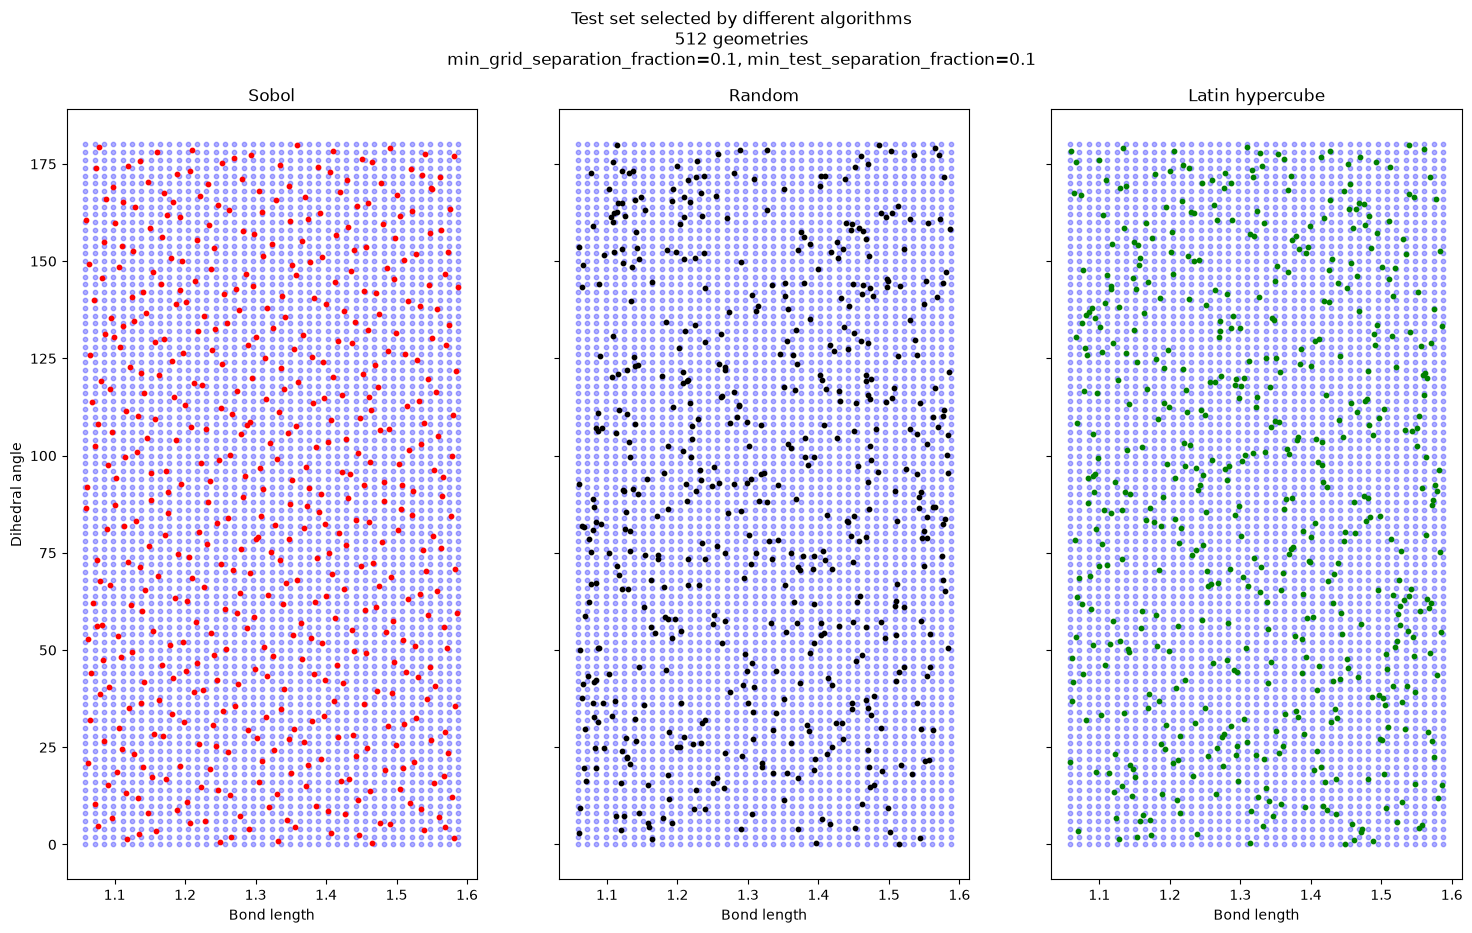

In [70]:
import matplotlib.pyplot as plt

sampling_sets = [
    ('Sobol', sobol_test_set, 'red'),
    ('Random', random_test_set, 'black'),
    ('Latin hypercube', latin_test_set, 'green'),
]

fig, axes = plt.subplots(1, 3, figsize=(18,10), sharex=True, sharey=True)
for ax, (name, sampled_atoms, color) in zip(axes, sampling_sets):
    sampled_bonds = [atoms.get_distance(0, 1) for atoms in sampled_atoms]
    sampled_dihedrals = [atoms.get_dihedral(4, 0, 1, 3) for atoms in sampled_atoms]
    ax.scatter(grid_bonds, grid_dihedrals, s=10, color='blue', alpha=0.3)
    ax.scatter(sampled_bonds, sampled_dihedrals, s=10, color=color)
    ax.set_title(name)
    ax.set_xlabel('Bond length')
axes[0].set_ylabel('Dihedral angle')
fig.suptitle(f'Test set selected by different algorithms' +
             f'\n{N_GEOMETRIES} geometries' +
             f'\nmin_grid_separation_fraction={min_grid_separation_fraction}, min_test_separation_fraction={min_test_separation_fraction}')
plt.show()


# 2. Generate data

Using `sobol_test_set`

### 2.1. Setup, check duration

In [ ]:
from pyscf import gto, scf, mcscf, fci

test_set = sobol_test_set

# PySCF returns energies in Hartree, but X-MACE expects eV.
HARTREE_TO_EV = 27.211386245988

# PySCF gradients are returned in Hartree / Bohr, even when the input XYZ is in Angstrom.
# This converts forces from Hartree / Bohr to eV / Angstrom.
BOHR_TO_ANGSTROM = 0.529177210903

def run_rhf(atoms, basis="sto-3g", charge=0):
    """
    Create a PySCF molecule from one ASE Atoms object and run RHF.
    """
    atom_spec = [
        (symbol, tuple(position))
        for symbol, position in zip(atoms.get_chemical_symbols(), atoms.get_positions())
    ]

    mol = gto.Mole()
    mol.atom = atom_spec
    mol.basis = basis
    mol.charge = charge
    mol.unit = "Angstrom"
    mol.verbose = 0 # Tell PYSCF to shut up
    mol.build()
    
    # Run Restricted Hartree Fock calculations to get Molecular Orbitals 
    mf = scf.RHF(mol)
    mf.conv_tol = 1.0e-10
    mf.kernel()

    return mf

def casscf_first_three_roots(atoms, active_space, basis="sto-3g", charge=0):
    """
    Run state-averaged CASSCF and return the first three roots.

    active_space is (num_electrons, num_orbitals), for example (2, 2).
    This means 2 active electrons in 2 active orbitals.

    Returns energies in eV and forces in eV per Angstrom 
    """
    n_roots = 3
    num_electrons, num_orbitals = active_space

    mf = run_rhf(atoms=atoms, basis=basis, charge=charge)

    mc = mcscf.CASSCF(mf, num_orbitals, num_electrons)
    mc.verbose = 0  # Tell PySCF to shut up.
    mc.fcisolver.verbose = 0
    mc.fcisolver.nroots = n_roots
    # Only keep singlet roots
    mc.fcisolver = fci.direct_spin0.FCI(mf.mol)

    # Multi-root CASSCF needs to know how to optimize the orbitals.
    # Equal-weight state averaging optimizes one orbital set for the first 3 roots.
    mc = mc.state_average_([1.0 / n_roots] * n_roots)
    mc.kernel()

    # CASSCF energies are returned in Hartree. Convert to eV.
    energies_hartree = np.asarray(mc.e_states, dtype=float).reshape(-1)[:n_roots]
    energies_ev = energies_hartree * HARTREE_TO_EV

    # PySCF returns gradients, dE/dR. Forces are the negative gradients.
    # The gradient unit is Hartree / Bohr, so convert to eV / Angstrom.
    gradient_method = mc.nuc_grad_method()
    gradient_method.verbose = 0
    forces_ev_per_angstrom = []

    for state_index in range(n_roots):
        gradient = gradient_method.kernel(state=state_index)
        force = -np.asarray(gradient) * HARTREE_TO_EV / BOHR_TO_ANGSTROM
        forces_ev_per_angstrom.append(force)

    forces_ev_per_angstrom = np.stack(forces_ev_per_angstrom, axis=0)

    return energies_ev, forces_ev_per_angstrom

In [74]:
import time

TOTAL_START = time.perf_counter()

for geometry_index, atoms in enumerate(test_set[:5]):
    GEOMETRY_START = time.perf_counter()

    CASSCF_22_START = time.perf_counter()
    casscf_22_energies, casscf_22_forces = casscf_first_three_roots(atoms=atoms, 
                                                                    active_space=[2, 2], 
                                                                    basis="cc-pVDZ", 
                                                                    charge=0)
    CASSCF_22_SECONDS = time.perf_counter() - CASSCF_22_START

    CASSCF_44_START = time.perf_counter()
    casscf_44_energies, casscf_44_forces = casscf_first_three_roots(atoms=atoms, 
                                                                    active_space=[4, 4], 
                                                                    basis="cc-pVDZ", 
                                                                    charge=0)
    CASSCF_44_SECONDS = time.perf_counter() - CASSCF_44_START

    GEOMETRY_SECONDS = time.perf_counter() - GEOMETRY_START

    print(f"Geometry {geometry_index}")
    print("CASSCF(2e,2o) energies:", casscf_22_energies)
    print("CASSCF(4e,4o) energies:", casscf_44_energies)
    print(f"CASSCF(2e,2o) time: {CASSCF_22_SECONDS:.2f} s")
    print(f"CASSCF(4e,4o) time: {CASSCF_44_SECONDS:.2f} s")
    print(f"Geometry total time: {GEOMETRY_SECONDS:.2f} s")
    print()

TOTAL_SECONDS = time.perf_counter() - TOTAL_START
print(f"Total time: {TOTAL_SECONDS:.2f} s")

Geometry 0
CASSCF(2e,2o) energies: [-3183.6802314  -3176.92441918 -3172.40594262]
CASSCF(4e,4o) energies: [-3184.66526942 -3178.14163404 -3176.62017344]
CASSCF(2e,2o) time: 65.94 s
CASSCF(4e,4o) time: 94.00 s
Geometry total time: 159.95 s

Geometry 1
CASSCF(2e,2o) energies: [-3181.9973032  -3176.93735418 -3175.53177579]
CASSCF(4e,4o) energies: [-3183.25084472 -3178.15851632 -3177.72712891]
CASSCF(2e,2o) time: 70.42 s
CASSCF(4e,4o) time: 88.01 s
Geometry total time: 158.44 s

Geometry 2
CASSCF(2e,2o) energies: [-3181.86320103 -3178.23964879 -3177.33567684]
CASSCF(4e,4o) energies: [-3183.12513454 -3179.04976919 -3178.7856617 ]
CASSCF(2e,2o) time: 56.95 s
CASSCF(4e,4o) time: 80.79 s
Geometry total time: 137.74 s

Geometry 3
CASSCF(2e,2o) energies: [-3180.85365791 -3171.95656166 -3163.86259086]
CASSCF(4e,4o) energies: [-3181.296921   -3173.40522127 -3171.34302152]
CASSCF(2e,2o) time: 70.39 s
CASSCF(4e,4o) time: 107.75 s
Geometry total time: 178.15 s

Geometry 4
CASSCF(2e,2o) energies: [-31

### 2.2. Generate 2e2o data

In [ ]:
OUTPUT_XYZ = DATA_DIR / "A02_propene_offgrid_512_sobol_2e2o.xyz"

for i, atoms in enumerate(test_set):
    atoms = atoms.copy()

    energies_ev, forces_ev_per_angstrom = casscf_first_three_roots(
        atoms=atoms,
        active_space=(2, 2),
        basis="cc-pVDZ",
        charge=0,
    )

    # Reshape to follow xyz file notation 
    atoms.info["REF_energy"] = np.asarray(energies_ev).reshape(1, -1)
    atoms.info["REF_forces"] = np.transpose(forces_ev_per_angstrom, (1, 0, 2))

    ase.io.write(
        OUTPUT_XYZ,
        atoms,
        format="extxyz",
        append=(i > 0),
    )

### 2.3. Generate 4e4o data

In [ ]:
OUTPUT_XYZ = DATA_DIR / "A02_propene_offgrid_512_sobol_4e4o.xyz"

for i, atoms in enumerate(test_set):
    atoms = atoms.copy()

    energies_ev, forces_ev_per_angstrom = casscf_first_three_roots(
        atoms=atoms,
        active_space=(4, 4),
        basis="cc-pVDZ",
        charge=0,
    )

    # Reshape to follow xyz file notation 
    atoms.info["REF_energy"] = np.asarray(energies_ev).reshape(1, -1)
    atoms.info["REF_forces"] = np.transpose(forces_ev_per_angstrom, (1, 0, 2))

    ase.io.write(
        OUTPUT_XYZ,
        atoms,
        format="extxyz",
        append=(i > 0),
    )